# 💻 Laptop Price Prediction 
## Machine Learning (ML)

This notebook builds machine learning models to predict laptop prices based on hardware specifications.

### Objectives
- Prepare dataset for modeling
- Train multiple regression models
- Evaluate performance
- Select the best model

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

OUTPUT_PATH = "../output/"
import joblib

import xgboost as xgb

### Load Processed Dataset

In [2]:
df = pd.read_csv("../data/laptop_cleaned.csv")

df.head()

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price,Screen,ScreenW,...,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model,ppi,Price_log
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640,226.983005,7.200940
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000,127.677940,6.802328
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620,141.211998,6.356108
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455,220.534624,7.839309
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650,226.983005,7.498094


## Feature Selection
Selecting relevant features for price prediction

In [3]:
X = df.drop(["Price","Price_log"], axis=1)
y = df["Price_log"]

## Train Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (1020, 23)
Testing size: (255, 23)


In [5]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical:", cat_cols)
print("Numerical:", num_cols)

Categorical: ['Company', 'Product', 'TypeName', 'OS', 'Screen', 'CPU_company', 'CPU_model', 'PrimaryStorageType', 'SecondaryStorageType', 'GPU_company', 'GPU_model']
Numerical: ['Inches', 'Ram', 'Weight', 'ScreenW', 'ScreenH', 'Touchscreen', 'IPSpanel', 'RetinaDisplay', 'CPU_freq', 'PrimaryStorage', 'SecondaryStorage', 'ppi']


## Data Preprocessing Pipeline
Encoding categorical features

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)])

## Linear Regression Model

In [8]:
lr_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)

In [9]:
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

MAE: 0.15279552391123646
RMSE: 0.20660949266204082
R2 Score: 0.875406018109726


## Random Forest Model

In [12]:
rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

In [13]:
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))

MAE: 0.1462313974682082
RMSE: 0.19235805005867512
R2 Score: 0.8920016165218665


## Xgboost Model

In [14]:
xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)

In [15]:
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R2 Score:", r2_score(y_test, y_pred_xgb))

MAE: 0.13769959973546594
RMSE: 0.17936750757647216
R2 Score: 0.9060960048241987


### Feature Importance
Understanding which features influence laptop price the most

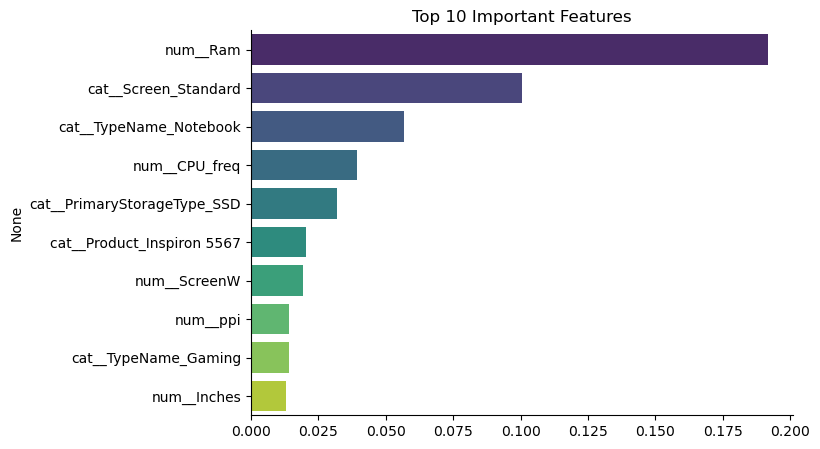

In [17]:
model = xgb_pipeline.named_steps["model"]

importances = model.feature_importances_

feature_names = xgb_pipeline.named_steps["preprocessing"].get_feature_names_out()

feat_imp = pd.Series(importances, index=feature_names)

feat_imp = feat_imp.sort_values(ascending=False).head(10)

plt.figure(figsize=(7,5))

sns.barplot(
    x=feat_imp.values,
    y=feat_imp.index,
    hue=feat_imp.index,
    palette="viridis",
    legend=False)

plt.title("Top 10 Important Features")

sns.despine()

plt.savefig("../output/Feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

## Model Performance Comparison

In [19]:
results = pd.DataFrame({
    "Model":["Linear Regression","Random Forest","XGBoost"],
    "R2":[
        r2_score(y_test,y_pred_lr),
        r2_score(y_test,y_pred_rf),
        r2_score(y_test,y_pred_xgb)]})

results

,Model,R2
0,Linear Regression,0.875406
1,Random Forest,0.892002
2,XGBoost,0.906096


### Model Performance Comparison
Comparing performance of all trained models

In [21]:
models = ["Linear Regression", "Random Forest", "XGBoost"]

scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_xgb)
]

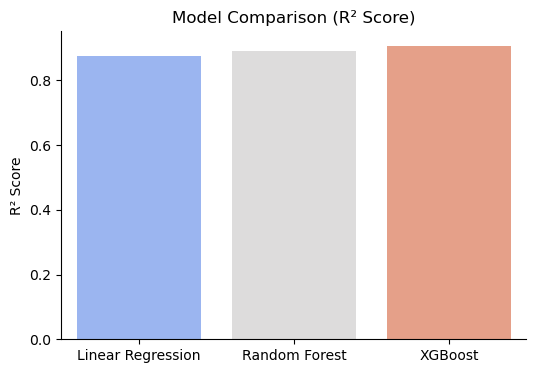

In [22]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=models,
    y=scores,
    hue=models,
    palette="coolwarm",
    legend=False)

plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")

sns.despine()
plt.savefig("../output/Model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## ACTUAL vs PREDICTED

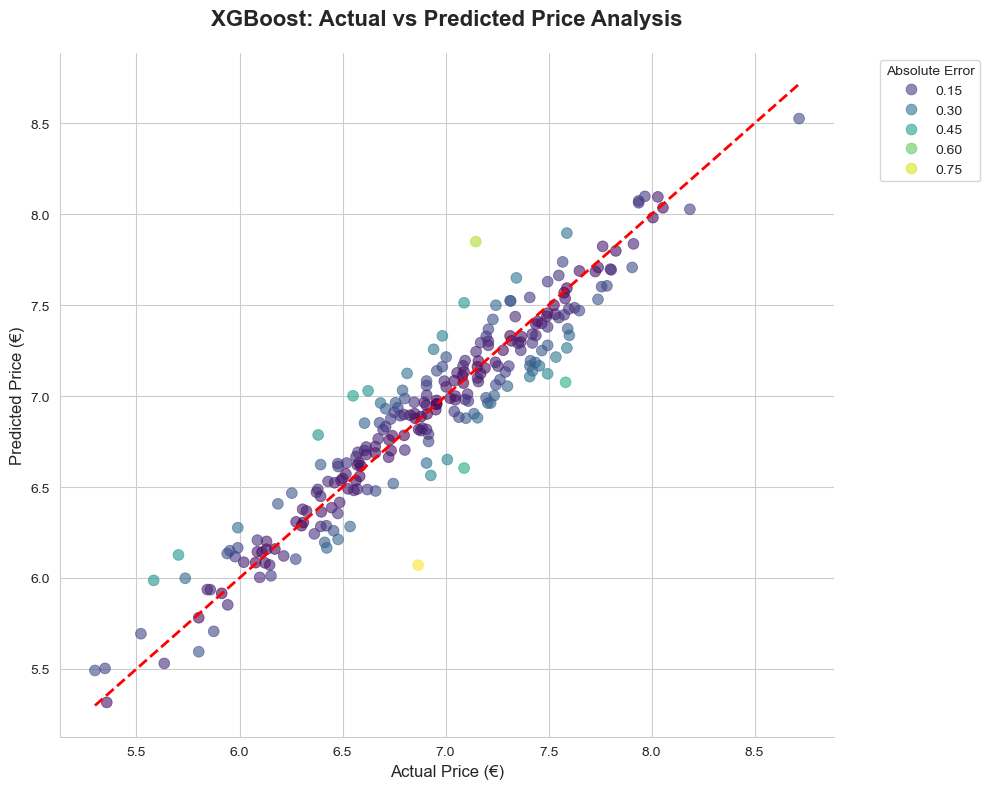

In [24]:
plt.figure(figsize=(10, 8))

sns.set_style("whitegrid")

error = np.abs(y_test - y_pred_xgb)

scatter = sns.scatterplot(
    x=y_test,
    y=y_pred_xgb,
    hue=error,
    palette="viridis",
    alpha=0.6,
    edgecolor=None,
    s=60)

max_val = max(max(y_test), max(y_pred_xgb))
min_val = min(min(y_test), min(y_pred_xgb))

plt.plot([min_val, max_val], [min_val, max_val], color="red", lw=2, linestyle="--")

plt.title("XGBoost: Actual vs Predicted Price Analysis", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Actual Price (€)", fontsize=12)
plt.ylabel("Predicted Price (€)", fontsize=12)

plt.legend(title="Absolute Error", bbox_to_anchor=(1.05, 1), loc="upper left")

sns.despine()

plt.savefig("../output/Actual_vs_Predicted.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Residual Error Analysis
Understanding prediction errors

In [26]:
residuals = y_test - y_pred_xgb

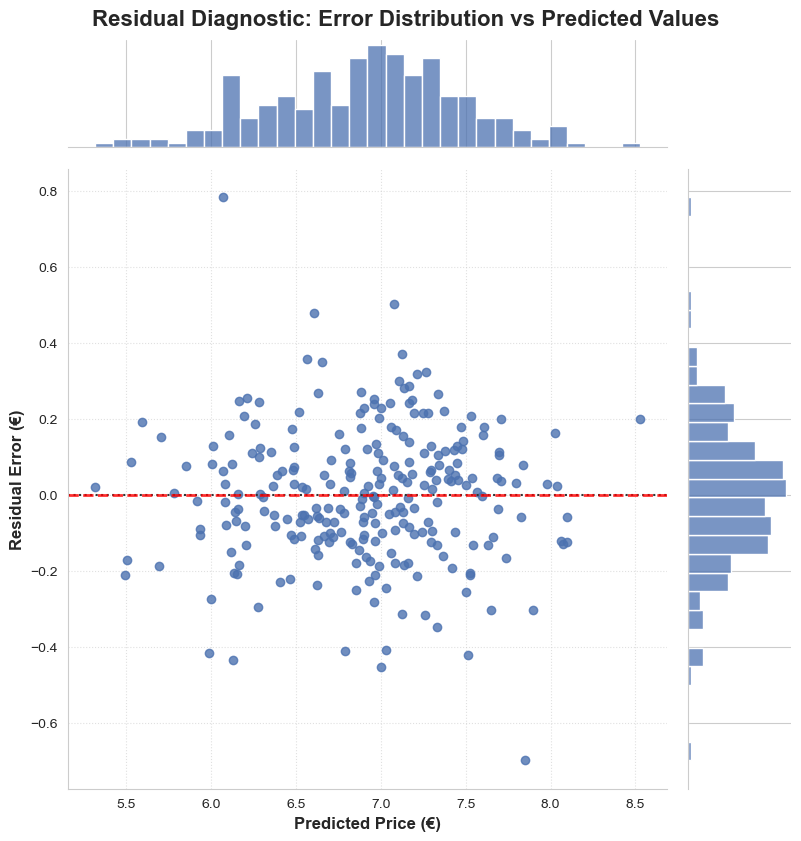

In [27]:
g = sns.jointplot(
    x=y_pred_xgb, 
    y=residuals, 
    kind="resid",
    height=8, 
    color="#4C72B0",
    marginal_kws=dict(bins=30, fill=True, color="#4C72B0"))
g.ax_joint.set_xlabel("Predicted Price (€)", fontsize=12, fontweight='bold')
g.ax_joint.set_ylabel("Residual Error (€)", fontsize=12, fontweight='bold')
g.ax_joint.axhline(0, color="red", linestyle="--", linewidth=2, alpha=0.8)
g.fig.suptitle("Residual Diagnostic: Error Distribution vs Predicted Values", 
               fontsize=16, fontweight='bold', y=1.02)
g.ax_joint.grid(True, linestyle=':', alpha=0.6)
plt.savefig("../output/Residual_error_pro.png", dpi=300, bbox_inches="tight")
plt.show()

In [28]:
joblib.dump(xgb_pipeline, "../output/laptop_price_model.pkl")

['../output/laptop_price_model.pkl']